# Mississippi River 7-Day Discharge Forecasting
This notebook develops a 7-day ahead discharge forecasting model using machine learning techniques.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded")


Libraries loaded


## 1. Data Loading and Initial Inspection
The dataset is loaded and basic structure, columns, and missing values are inspected.


In [2]:
df = pd.read_csv("final_flood_dataset_1981_onwards.csv")

df["date"] = pd.to_datetime(df["date"])

print("Shape:", df.shape)
df.head()


Shape: (16388, 12)


,date,discharge_stl,gage_stl,discharge_keokuk,discharge_grafton,discharge_thebes,T2M,PS,WS2M,RH2M,T2M_MAX,PRECTOT
0,1981-01-01,75300.0,5.53,34000.0,502.0,77900.0,0.39,100.22,3.53,81.50,4.89,0.08
1,1981-01-02,76700.0,5.53,32000.0,494.0,78400.0,-0.71,100.50,2.18,68.67,6.01,0.00
2,1981-01-03,76900.0,5.53,33700.0,491.0,80200.0,-3.15,100.30,3.80,57.55,0.66,0.00
3,1981-01-04,75100.0,5.53,34200.0,492.0,80700.0,-9.82,101.53,2.66,46.45,-5.75,0.00
4,1981-01-05,66500.0,5.53,30400.0,494.0,80400.0,-6.85,101.08,2.87,57.51,-1.93,0.05


In [3]:
print(df.columns)
print(df.isnull().sum())


Index(['date', 'discharge_stl', 'gage_stl', 'discharge_keokuk',
       'discharge_grafton', 'discharge_thebes', 'T2M', 'PS', 'WS2M', 'RH2M',
       'T2M_MAX', 'PRECTOT'],
      dtype='str')
date                 0
discharge_stl        0
gage_stl             0
discharge_keokuk     0
discharge_grafton    0
discharge_thebes     0
T2M                  0
PS                   0
WS2M                 0
RH2M                 0
T2M_MAX              0
PRECTOT              0
dtype: int64


In [4]:
df["discharge_stl"].describe()


count    1.638800e+04
mean     2.287352e+05
std      1.413055e+05
min      4.120000e+04
25%      1.210000e+05
50%      1.860000e+05
75%      3.020000e+05
max      1.050000e+06
Name: discharge_stl, dtype: float64

## 2. Exploratory Data Analysis
Distribution of St. Louis discharge values is visualized to understand data characteristics.

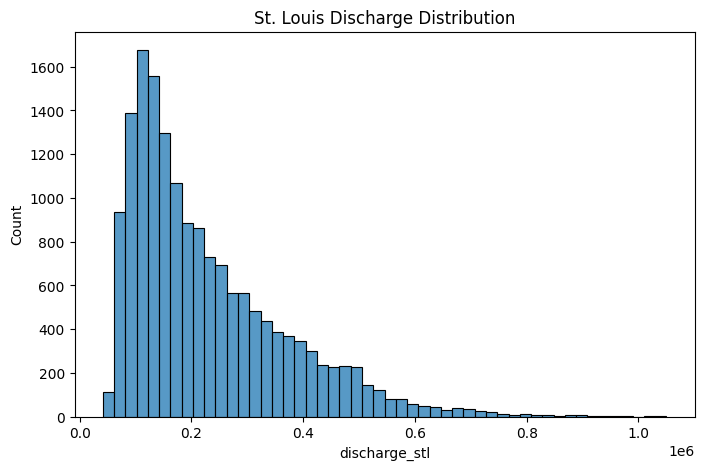

In [5]:
plt.figure(figsize=(8,5))
sns.histplot(df["discharge_stl"], bins=50)
plt.title("St. Louis Discharge Distribution")
plt.show()


## 3. Feature Engineering
Time-aware features are created including rainfall accumulation and lagged discharge values.

In [6]:
# Rain accumulation
df["rain_3day"] = df["PRECTOT"].rolling(3).sum()
df["rain_7day"] = df["PRECTOT"].rolling(7).sum()

# Upstream lag features
df["keokuk_lag1"] = df["discharge_keokuk"].shift(1)
df["keokuk_lag3"] = df["discharge_keokuk"].shift(3)

# Local lag features
df["stl_lag1"] = df["discharge_stl"].shift(1)
df["stl_lag3"] = df["discharge_stl"].shift(3)

# Remove rows with NaN from shifting
df = df.dropna()

df.shape


(16382, 18)

## 4. Target Creation (7-Day Ahead Forecast)
The model is designed to predict discharge 7 days into the future.

In [7]:
# Create 7-day ahead discharge target
df["discharge_future"] = df["discharge_stl"].shift(-7)

# Remove rows without future values
df = df.dropna()

df.shape


(16375, 19)

In [8]:
X = df[[
    "T2M",
    "PS",
    "WS2M",
    "RH2M",
    "PRECTOT",
    "rain_3day",
    "rain_7day",
    "keokuk_lag1",
    "keokuk_lag3",
    "stl_lag1",
    "stl_lag3"
]]

y = df["discharge_future"]


## 5. Train-Test Split
A chronological 80/20 time-based split is used to prevent data leakage.

In [9]:
split = int(len(df) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

print("Train:", X_train.shape)
print("Test:", X_test.shape)


Train: (13100, 11)
Test: (3275, 11)


## 6. Random Forest Regression Model
A Random Forest Regressor is trained for 7-day ahead discharge prediction.

In [10]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

print("Model trained.")


Model trained.


In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

pred = model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))

print("MAE:", mae)
print("RMSE:", rmse)


MAE: 46569.78921119594
RMSE: 66029.15452681443


## 7. Baseline Model (Persistence)
A naive persistence model is used as a reference benchmark.

In [12]:
# ---- Baseline Model (Persistence) ----

# Baseline = today's discharge predicts 7 days ahead
baseline_pred = df["discharge_stl"].shift(0).iloc[split:].values

# Ensure same length as y_test
baseline_pred = baseline_pred[:len(y_test)]

baseline_mae = np.mean(np.abs(y_test.values - baseline_pred))
baseline_rmse = np.sqrt(np.mean((y_test.values - baseline_pred) ** 2))

print("Baseline MAE:", baseline_mae)
print("Baseline RMSE:", baseline_rmse)


Baseline MAE: 43407.88804071246
Baseline RMSE: 64416.39826995098


## 8. Gradient Boosting Regression Model
A Gradient Boosting model is implemented to improve forecast accuracy.

In [13]:
# ---- Gradient Boosting Model ----

from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gbr.fit(X_train, y_train)

gbr_pred = gbr.predict(X_test)

gbr_mae = mean_absolute_error(y_test, gbr_pred)
gbr_rmse = np.sqrt(mean_squared_error(y_test, gbr_pred))

print("GBR MAE:", gbr_mae)
print("GBR RMSE:", gbr_rmse)


GBR MAE: 42604.18290199802
GBR RMSE: 61549.824778858354


## 9. Feature Importance Analysis
Feature importance is analyzed to understand dominant predictors.

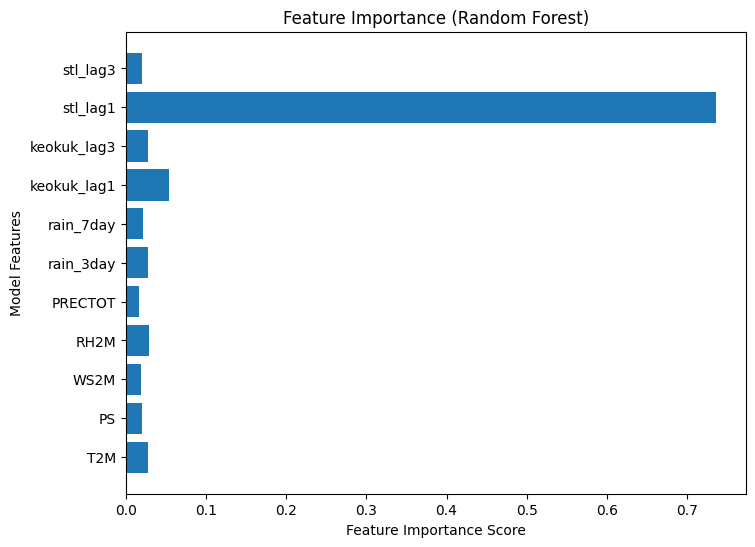

In [14]:
# ---- Feature Importance (Random Forest) ----

importances = model.feature_importances_
feature_names = X.columns



plt.figure(figsize=(8,6))
plt.barh(feature_names, importances)
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Feature Importance Score")
plt.ylabel("Model Features")

plt.show()


## 10. Forecast Visualization
Actual and predicted discharge values are compared for the test period.

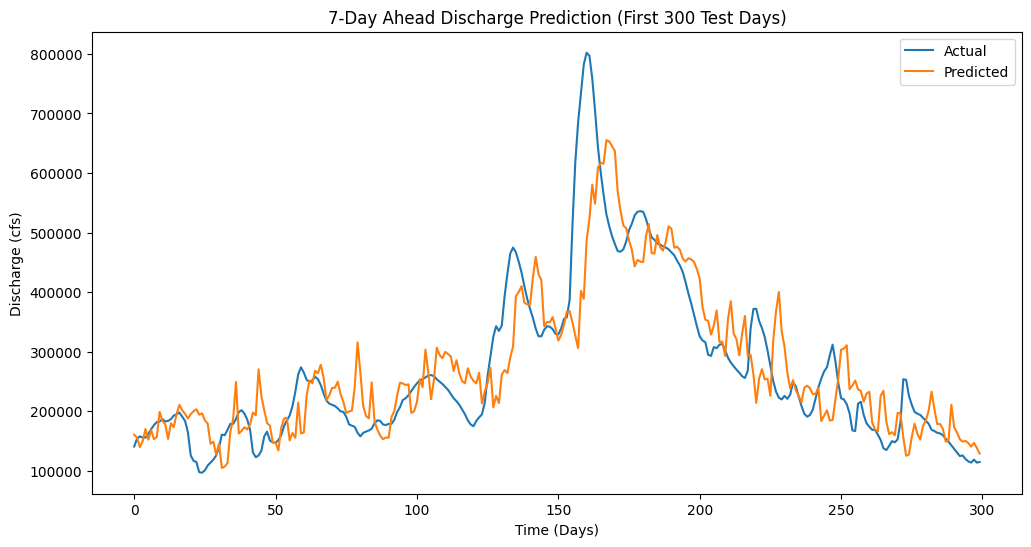

In [15]:
plt.figure(figsize=(12,6))
plt.plot(y_test.values[:300], label="Actual")
plt.plot(pred[:300], label="Predicted")
plt.legend()
plt.xlabel("Time (Days)")
plt.ylabel("Discharge (cfs)")

plt.title("7-Day Ahead Discharge Prediction (First 300 Test Days)")
plt.show()


In [16]:
print("Baseline RMSE:", baseline_rmse)
print("Random Forest RMSE:", rmse)
print("Gradient Boosting RMSE:", gbr_rmse)


Baseline RMSE: 64416.39826995098
Random Forest RMSE: 66029.15452681443
Gradient Boosting RMSE: 61549.824778858354


## Conclusion

The Gradient Boosting model achieved the best performance, improving upon the persistence baseline by approximately 4–5%.

Results indicate strong temporal autocorrelation in river discharge, with lagged discharge features dominating short-term forecasting performance.

The modest improvement over the baseline highlights the strong persistence characteristics of large river systems such as the Mississippi.
